# Incremental value of football-form features beyond the market

## Does simple team form improve market-implied probabilities?

This notebook tests a market-efficiency question: whether simple attacking and defensive team-form features add out-of-sample information beyond the bookmaker-consensus market probability.

The market-implied probability is the natural benchmark because bookmaker odds already contain most public football information. Therefore, the central comparison is not whether form features predict Over 2.5 in isolation, but whether they improve a market-anchored probability model.

The notebook remains experimental. It does **not** change the main strategy notebook unless the evidence is stable across seasons, metrics, execution sources, and regularization settings.

In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    build_execution_candidates,
    build_research_dataset,
    monthly_roi,
    probability_performance,
    run_pooled_rolling_walk_forward,
    summarize_bets,
)
from football_edge.config import MINIMUM_EXPECTED_VALUE, RAW_DATA_DIR
from football_edge.data import discover_datasets

pd.set_option("display.max_columns", 40)
plt.style.use("seaborn-v0_8-whitegrid")

TRAINING_WINDOW = 2
BASE_L2 = 100.0
SENSITIVITY_L2_VALUES = [10.0, 100.0, 300.0, 1000.0]
EV_THRESHOLD = MINIMUM_EXPECTED_VALUE

ATTACK_FEATURES = [
    "home_season_avg_goals",
    "away_season_avg_goals",
    "home_last_5_avg_goals",
    "away_last_5_avg_goals",
]
DEFENSE_FEATURES = [
    "home_season_avg_goals_conceded",
    "away_season_avg_goals_conceded",
    "home_last_5_goals_conceded",
    "away_last_5_goals_conceded",
]

MODEL_SPECS = {
    "Market only": ["market_logit"],
    "Football form only": [*ATTACK_FEATURES, *DEFENSE_FEATURES],
    "Current model": ["market_logit", *ATTACK_FEATURES],
    "Expanded model": ["market_logit", *ATTACK_FEATURES, *DEFENSE_FEATURES],
}
MODEL_ORDER = list(MODEL_SPECS)
MODEL_COLORS = {
    "Market only": "#1B9E77",
    "Football form only": "#D95F02",
    "Current model": "#7570B3",
    "Expanded model": "#E7298A",
}
SOURCE_ORDER = [
    "bet365",
    "pinnacle",
    "betfair_exchange",
    "average_preclosing",
    "best_preclosing",
    "best_closing",
]
SOURCE_LABELS = {
    "bet365": "Bet365",
    "pinnacle": "Pinnacle",
    "betfair_exchange": "Betfair Exchange",
    "average_preclosing": "Market average",
    "best_preclosing": "Market maximum",
    "best_closing": "Closing maximum*",
}
PREDICTIVE_METRICS = {
    "brier_score": "Brier score (lower is better)",
    "log_loss": "Log loss (lower is better)",
    "calibration_slope": "Calibration slope (target near 1)",
    "calibration_intercept": "Calibration intercept (target near 0)",
}


def order_categories(frame, column, order):
    result = frame.copy()
    result[column] = pd.Categorical(result[column], categories=order, ordered=True)
    return result.sort_values(column)


def add_zero_line(axis, *, vertical=False):
    if vertical:
        axis.axvline(0, color="black", linewidth=1, alpha=0.8)
    else:
        axis.axhline(0, color="black", linewidth=1, alpha=0.8)


def add_target_line(axis, metric):
    if metric == "calibration_slope":
        axis.axhline(1, color="black", linewidth=1, alpha=0.8)
    elif metric == "calibration_intercept":
        axis.axhline(0, color="black", linewidth=1, alpha=0.8)


def plot_panel_legend(figure, handles, labels, y=0.985):
    by_label = dict(zip(labels, handles))
    figure.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        ncol=min(len(by_label), 4),
        frameon=True,
        bbox_to_anchor=(0.5, y),
    )

## 1. Experimental design

Four prespecified feature sets are compared on the same common sample and walk-forward folds:

1. **Market only**: `market_logit` only.
2. **Football form only**: attacking and defensive/conceded-goal form, without market odds.
3. **Current model**: market logit plus attacking-form features.
4. **Expanded model**: market logit plus attacking and defensive/conceded-goal features.

The main benchmark comparisons are:

$$
\text{Current model} - \text{Market only}
$$

$$
\text{Expanded model} - \text{Market only}
$$

A secondary comparison checks whether defensive features add anything beyond the current attacking-form model:

$$
\text{Expanded model} - \text{Current model}
$$

For Brier score, log loss, and absolute calibration error, negative deltas are better. Economic outcomes such as ROI and CLV are shown afterwards, but they are treated as secondary because they are much noisier than proper scoring metrics.

In [13]:
datasets = discover_datasets(RAW_DATA_DIR)
all_matches = build_research_dataset(datasets)

required_features = sorted({feature for features in MODEL_SPECS.values() for feature in features})
missing = set(required_features).difference(all_matches.columns)
if missing:
    raise ValueError(f"Missing engineered features: {sorted(missing)}")

common_required_columns = required_features + ["league", "season", "date", "over_2_5"]
analysis_matches = all_matches.dropna(subset=common_required_columns).copy()

print(f"Raw engineered matches: {len(all_matches):,}")
print(f"Common model-comparison sample: {len(analysis_matches):,}")
print("The common sample is used for every feature set so model differences are not driven by missing-history rows.")
analysis_matches[common_required_columns].head()

Raw engineered matches: 7,230
Common model-comparison sample: 7,034
The common sample is used for every feature set so model differences are not driven by missing-history rows.


,away_last_5_avg_goals,away_last_5_goals_conceded,away_season_avg_goals,away_season_avg_goals_conceded,home_last_5_avg_goals,home_last_5_goals_conceded,home_season_avg_goals,home_season_avg_goals_conceded,market_logit,league,season,date,over_2_5
9,5.0,1.0,5.0,1.0,0.0,1.0,0.0,1.0,0.513454,Bundesliga,21_22,2021-08-20 19:30:00,1
10,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.156569,Bundesliga,21_22,2021-08-21 14:30:00,0
11,0.0,4.0,0.0,4.0,2.0,5.0,2.0,5.0,0.447312,Bundesliga,21_22,2021-08-21 14:30:00,0
12,5.0,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.582518,Bundesliga,21_22,2021-08-21 14:30:00,1
13,0.0,0.0,0.0,0.0,1.0,5.0,1.0,5.0,-0.078369,Bundesliga,21_22,2021-08-21 14:30:00,0


## 2. Walk-forward predictions

Every model uses the same chronological validation rule: train one pooled all-league model using only the previous two seasons, then test on the next season. League dummy variables are included inside the reusable walk-forward function, so the compared feature sets share the same league-baseline treatment.

In [14]:
prediction_frames = []
coefficient_frames = []
for model_name, features in MODEL_SPECS.items():
    predictions, coefficients = run_pooled_rolling_walk_forward(
        analysis_matches,
        l2=BASE_L2,
        model_name=model_name,
        training_window=TRAINING_WINDOW,
        feature_columns=features,
    )
    predictions["feature_set"] = model_name
    coefficients["feature_set"] = model_name
    prediction_frames.append(predictions)
    coefficient_frames.append(coefficients)

model_predictions = pd.concat(prediction_frames, ignore_index=True)
model_coefficients = pd.concat(coefficient_frames, ignore_index=True)

sample_counts = model_predictions.groupby("model_name").size()
assert sample_counts.nunique() == 1
assert (model_predictions["train_end_date"] < model_predictions["test_start_date"]).all()
assert model_predictions["model_probability"].between(0, 1).all()

season_order = sorted(model_predictions["season"].unique())
print(f"Models compared: {len(MODEL_SPECS)}")
print(f"Predictions per model: {sample_counts.iloc[0]:,}")
print(f"Test seasons: {', '.join(season_order)}")

Models compared: 4
Predictions per model: 4,221
Test seasons: 23_24, 24_25, 25_26


## 3. Predictive performance by season

These are the primary diagnostics. If simple football-form features add real incremental information, the current or expanded market-anchored models should improve Brier score and log loss versus the market-only benchmark consistently through time.

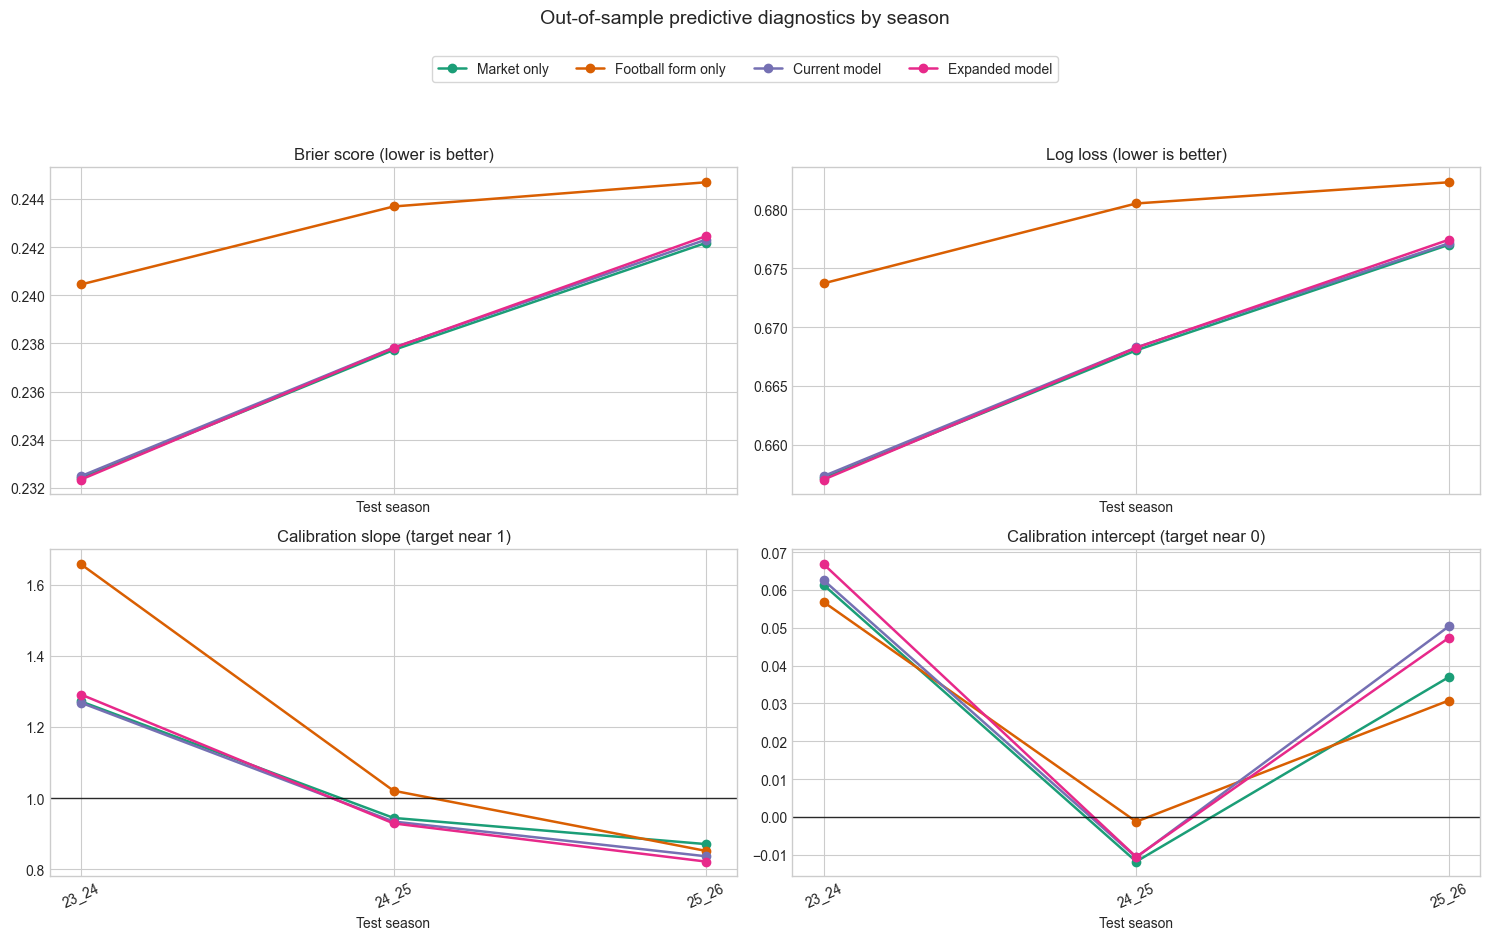

In [15]:
season_performance = probability_performance(
    model_predictions,
    probability_column="model_probability",
    group_by=["model_name", "season"],
)
season_performance = order_categories(season_performance, "model_name", MODEL_ORDER)

figure, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
axes = axes.ravel()
handles, labels = [], []
for axis, (metric, ylabel) in zip(axes, PREDICTIVE_METRICS.items()):
    for model_name in MODEL_ORDER:
        subset = season_performance.loc[season_performance["model_name"].eq(model_name)]
        line = axis.plot(
            subset["season"],
            subset[metric],
            marker="o",
            linewidth=1.8,
            color=MODEL_COLORS[model_name],
            label=model_name,
        )[0]
        handles.append(line)
        labels.append(model_name)
    add_target_line(axis, metric)
    axis.set_title(ylabel)
    axis.set_xlabel("Test season")
    axis.tick_params(axis="x", rotation=25)

plot_panel_legend(figure, handles, labels, y=0.995)
figure.suptitle("Out-of-sample predictive diagnostics by season", y=1.04, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 4. Incremental value relative to the market benchmark

This is the key section. The market-only model is the benchmark. Bars below zero mean the feature-augmented model improves the metric relative to the benchmark.

Three comparisons are shown:

- **Current - Market**: do attacking-form features add value beyond the market?
- **Expanded - Market**: do attacking plus defensive/conceded features add value beyond the market?
- **Expanded - Current**: do defensive/conceded features add value beyond attacking form?

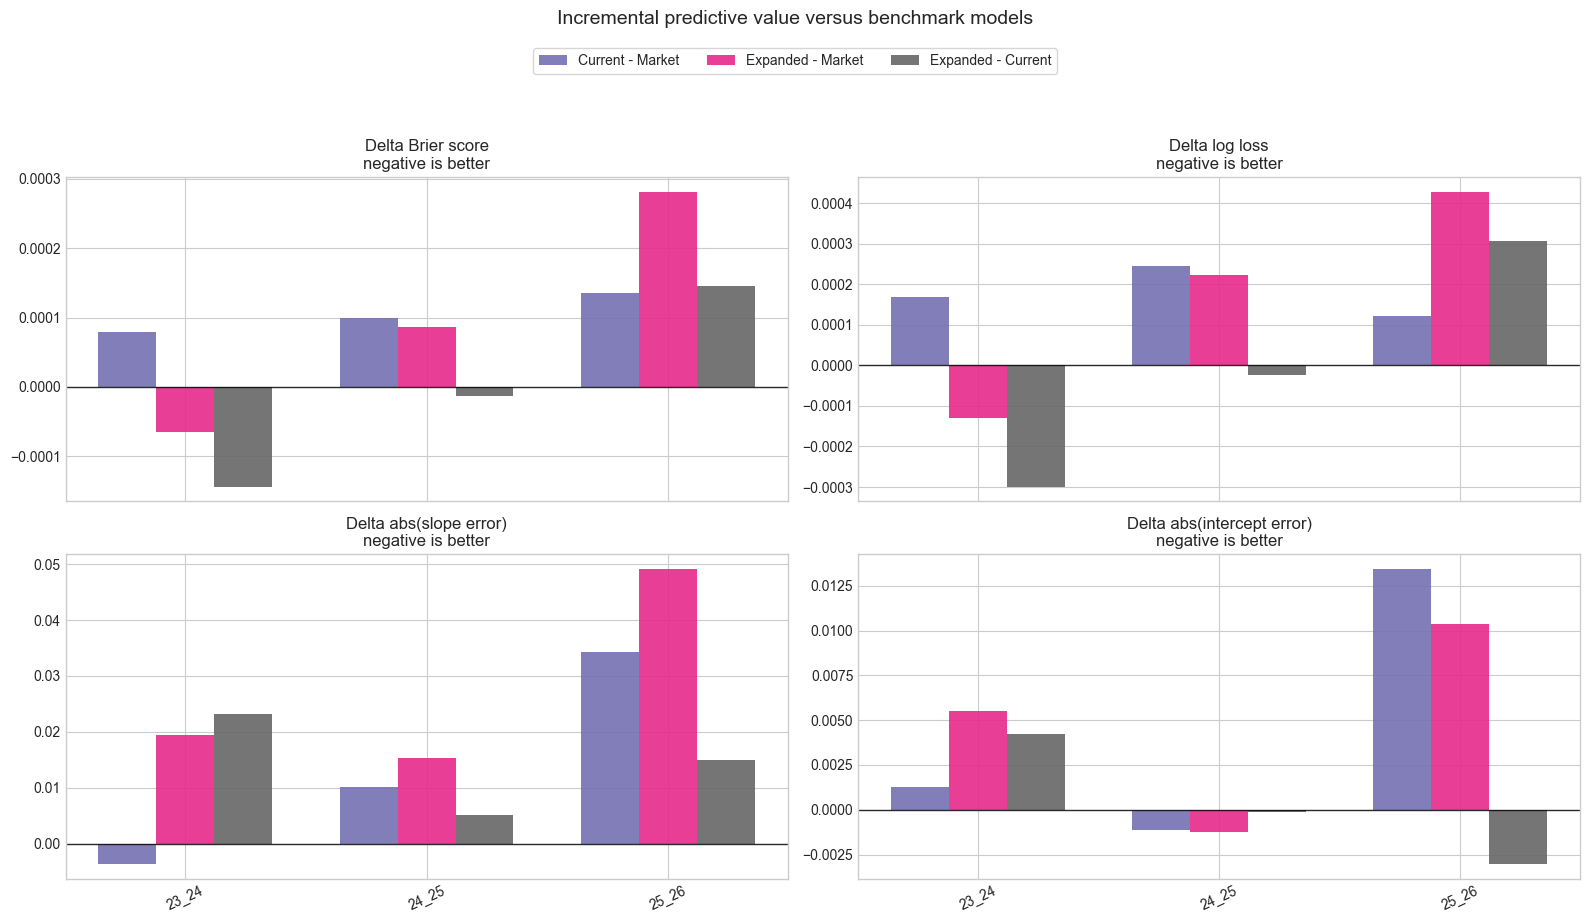

In [16]:
comparison = season_performance.pivot(index="season", columns="model_name")

BENCHMARK_COMPARISONS = {
    "Current - Market": ("Current model", "Market only"),
    "Expanded - Market": ("Expanded model", "Market only"),
    "Expanded - Current": ("Expanded model", "Current model"),
}
DELTA_COLORS = {
    "Current - Market": "#7570B3",
    "Expanded - Market": "#E7298A",
    "Expanded - Current": "#666666",
}

delta_rows = []
for label, (candidate, benchmark) in BENCHMARK_COMPARISONS.items():
    for season in season_order:
        delta_rows.append(
            {
                "comparison": label,
                "season": season,
                "delta_brier": comparison.loc[season, ("brier_score", candidate)]
                - comparison.loc[season, ("brier_score", benchmark)],
                "delta_log_loss": comparison.loc[season, ("log_loss", candidate)]
                - comparison.loc[season, ("log_loss", benchmark)],
                "delta_abs_calibration_slope_error": abs(
                    comparison.loc[season, ("calibration_slope", candidate)] - 1
                )
                - abs(comparison.loc[season, ("calibration_slope", benchmark)] - 1),
                "delta_abs_calibration_intercept_error": abs(
                    comparison.loc[season, ("calibration_intercept", candidate)]
                )
                - abs(comparison.loc[season, ("calibration_intercept", benchmark)]),
            }
        )
delta_frame = pd.DataFrame(delta_rows)

plot_specs = [
    ("delta_brier", "Delta Brier score\nnegative is better"),
    ("delta_log_loss", "Delta log loss\nnegative is better"),
    ("delta_abs_calibration_slope_error", "Delta abs(slope error)\nnegative is better"),
    ("delta_abs_calibration_intercept_error", "Delta abs(intercept error)\nnegative is better"),
]

figure, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
axes = axes.ravel()
bar_width = 0.24
season_x = np.arange(len(season_order))
comparison_order = list(BENCHMARK_COMPARISONS)
for axis, (column, title) in zip(axes, plot_specs):
    for offset_index, comparison_name in enumerate(comparison_order):
        subset = delta_frame.loc[delta_frame["comparison"].eq(comparison_name)].set_index("season").reindex(season_order)
        offset = (offset_index - (len(comparison_order) - 1) / 2) * bar_width
        axis.bar(
            season_x + offset,
            subset[column],
            width=bar_width,
            color=DELTA_COLORS[comparison_name],
            label=comparison_name,
            alpha=0.9,
        )
    add_zero_line(axis)
    axis.set_title(title)
    axis.set_xticks(season_x, season_order, rotation=25)

handles, labels = axes[0].get_legend_handles_labels()
plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Incremental predictive value versus benchmark models", y=1.02, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 5. Coefficient stability in the expanded model

Stable incremental information should show coherent coefficient behavior across walk-forward folds. Coefficients are standardized fold coefficients, so their magnitudes are comparable within a model fit. League dummy variables are omitted from this plot because the question is about market, attacking-form, and defensive-form predictors.

The expected pattern for a useful market-anchored model is that the market-logit coefficient is stable and dominant, while any genuinely incremental football features should show consistent signs or magnitudes rather than fold-to-fold noise.

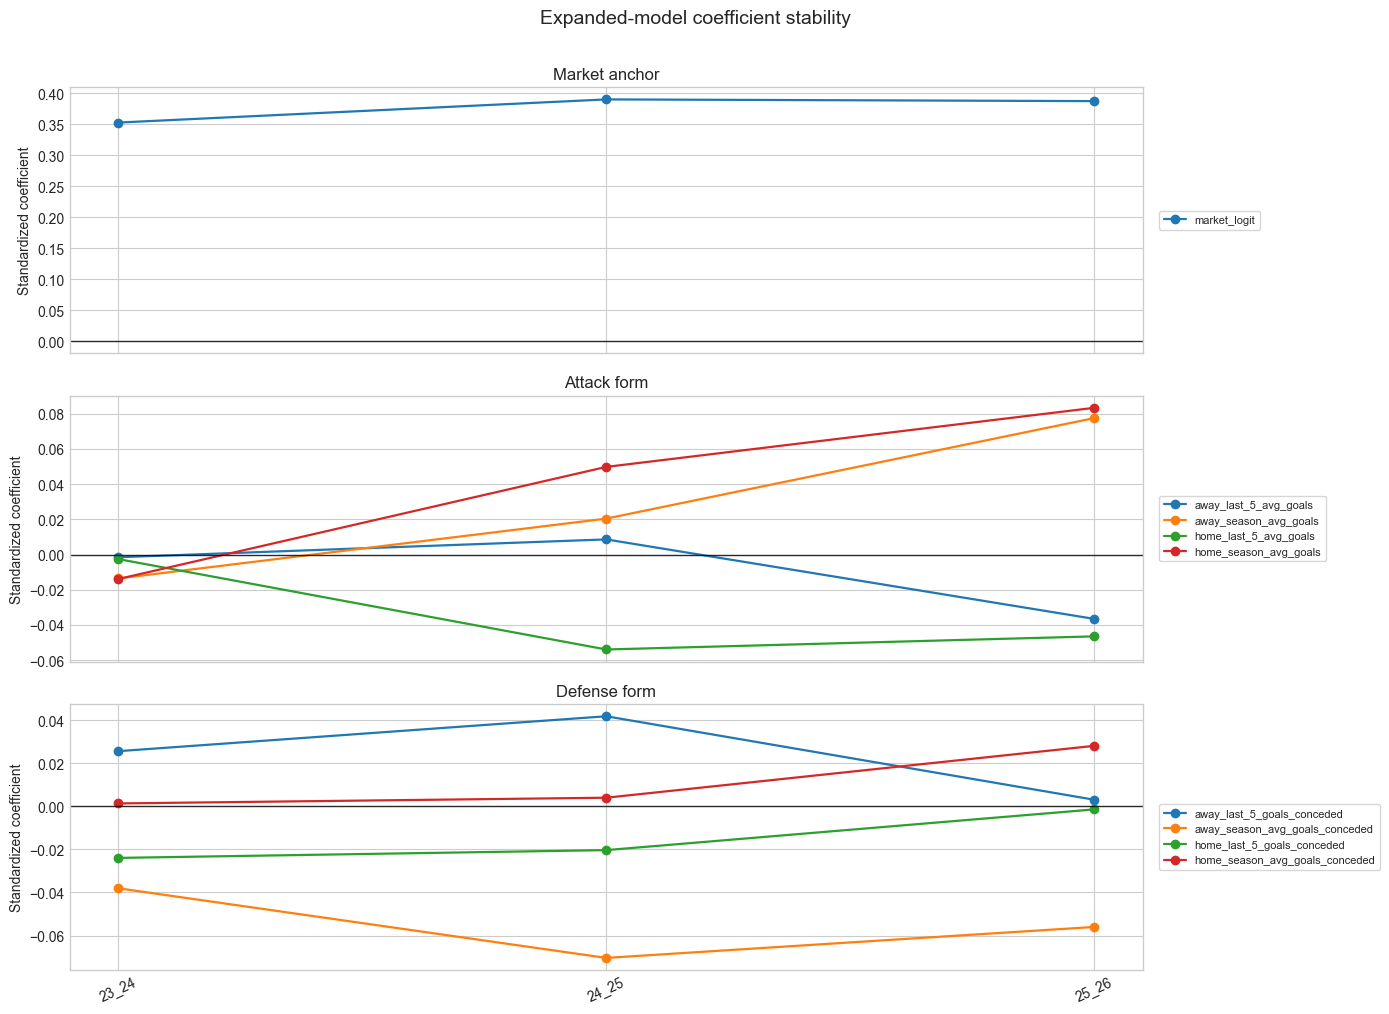

In [17]:
feature_group = {
    "market_logit": "Market anchor",
    **{feature: "Attack form" for feature in ATTACK_FEATURES},
    **{feature: "Defense form" for feature in DEFENSE_FEATURES},
}
GROUP_COLORS = {
    "Market anchor": "#1B9E77",
    "Attack form": "#7570B3",
    "Defense form": "#E7298A",
}
expanded_coefficients = model_coefficients.loc[
    model_coefficients["model_name"].eq("Expanded model")
    & model_coefficients["coefficient"].isin(feature_group)
].copy()
expanded_coefficients["feature_group"] = expanded_coefficients["coefficient"].map(feature_group)

figure, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for axis, group in zip(axes, ["Market anchor", "Attack form", "Defense form"]):
    subset = expanded_coefficients.loc[expanded_coefficients["feature_group"].eq(group)]
    for coefficient, coefficient_data in subset.groupby("coefficient", sort=True):
        axis.plot(
            coefficient_data["test_season"],
            coefficient_data["value"],
            marker="o",
            linewidth=1.6,
            label=coefficient,
        )
    add_zero_line(axis)
    axis.set_title(group)
    axis.set_ylabel("Standardized coefficient")
    axis.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=True)
    axis.tick_params(axis="x", rotation=25)

figure.suptitle("Expanded-model coefficient stability", y=1.01, fontsize=14)
figure.tight_layout()
plt.show()

## 6. Economic diagnostics by season and execution source

Economic results are evaluated with the same fixed 3% EV threshold. These plots are secondary to the predictive diagnostics, but they show whether any predictive improvement maps into selected bets, ROI, and CLV.

The closing maximum is retained only as a non-executable sensitivity.

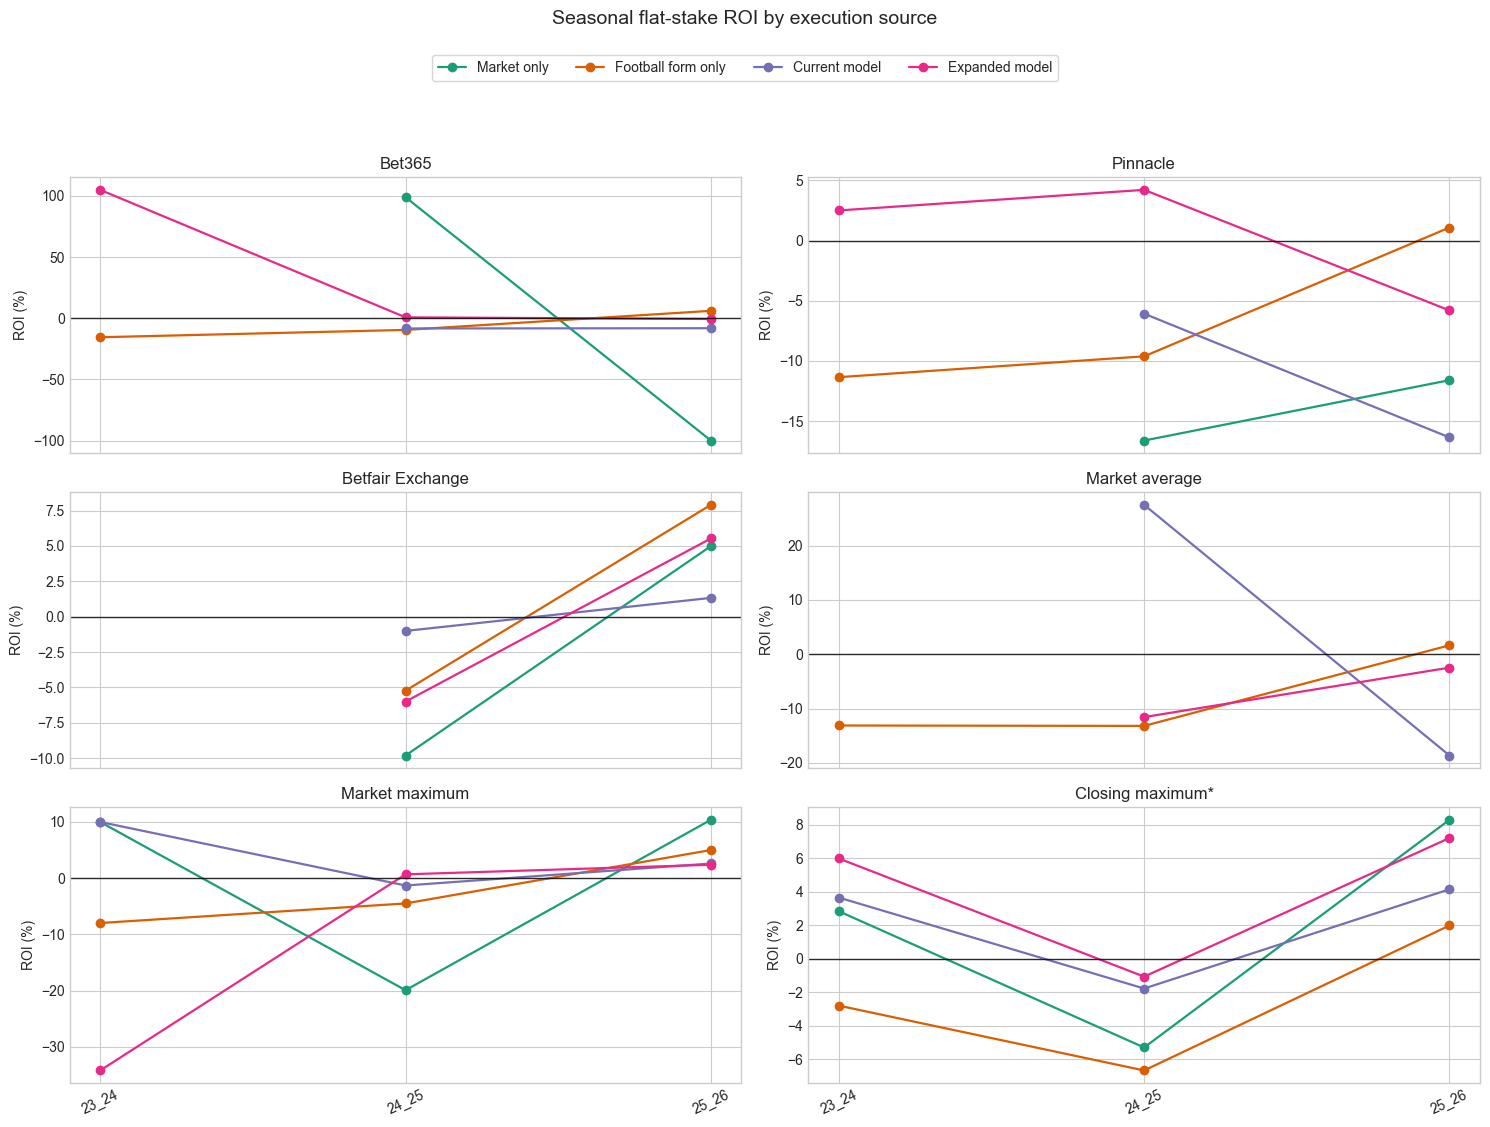

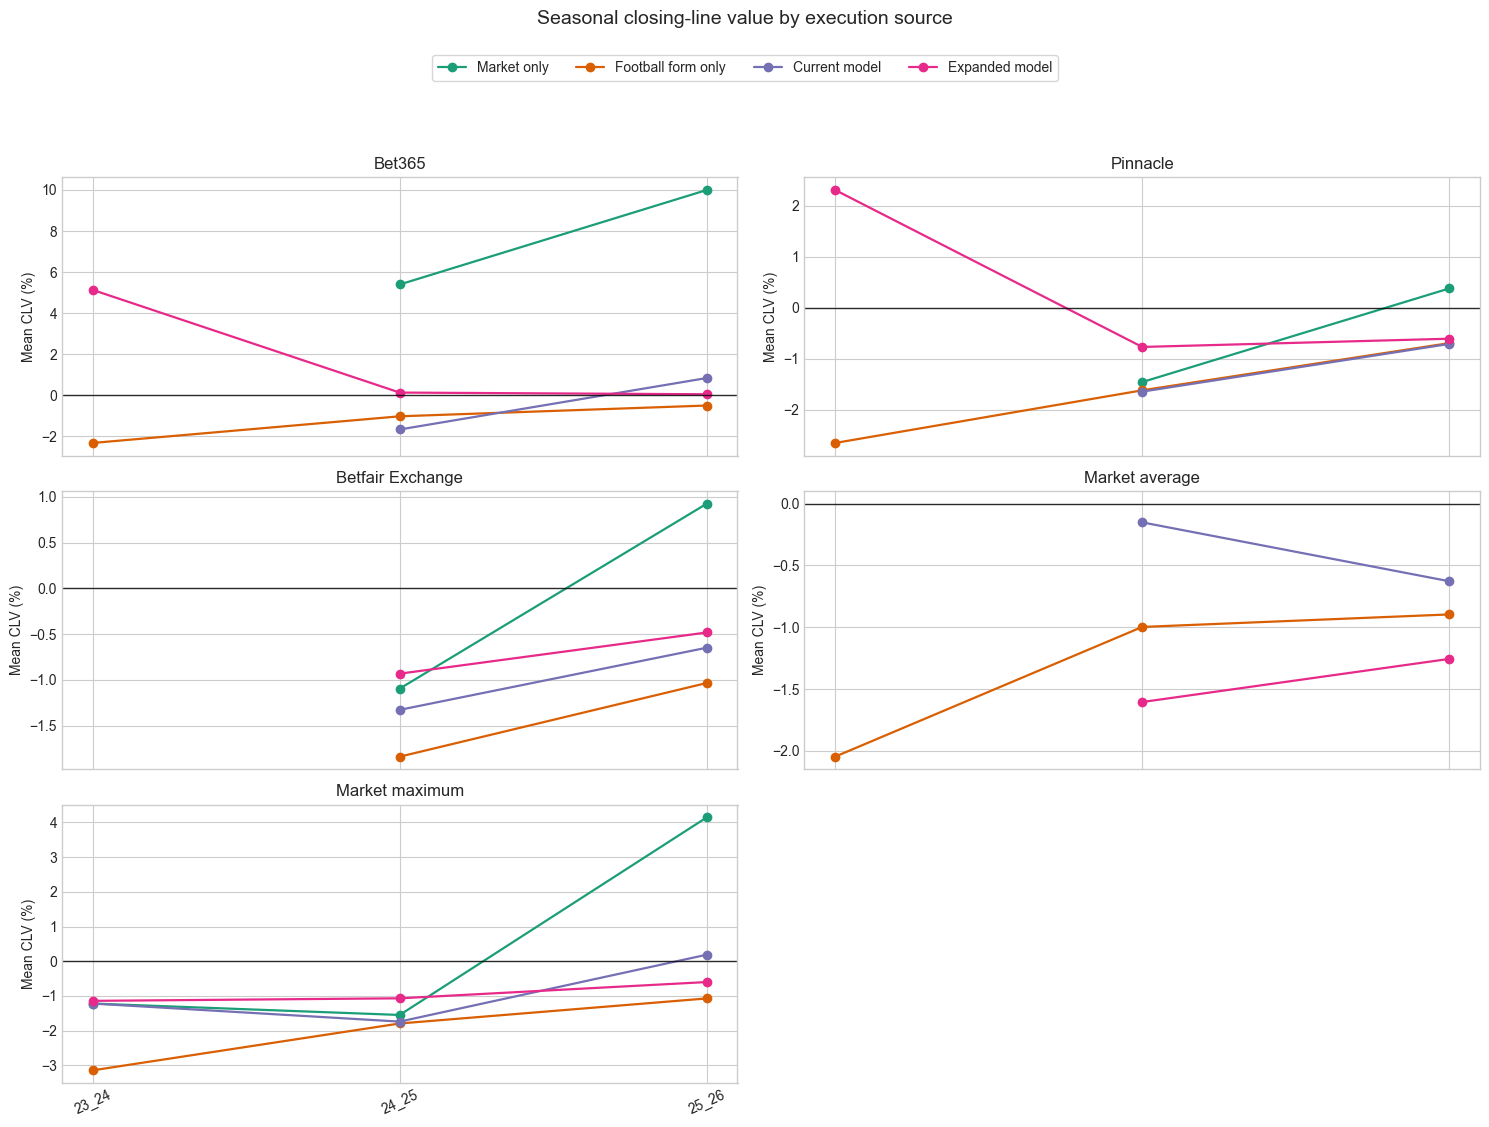

In [18]:
candidate_frames = []
bet_frames = []
for model_name, predictions in model_predictions.groupby("model_name", sort=False):
    candidates = build_execution_candidates(
        predictions,
        include_closing_prices=True,
        probability_column="model_probability",
    )
    candidates["model_name"] = model_name
    candidate_frames.append(candidates)
    bets = candidates.loc[candidates["expected_value"].ge(EV_THRESHOLD)].copy()
    bets["model_name"] = model_name
    bet_frames.append(bets)

all_candidates = pd.concat(candidate_frames, ignore_index=True)
all_bets = pd.concat(bet_frames, ignore_index=True)

bet_summary = summarize_bets(all_bets, ["model_name", "execution_source"])
season_bet_summary = summarize_bets(
    all_bets, ["model_name", "execution_source", "season"]
)
season_bet_summary = order_categories(season_bet_summary, "model_name", MODEL_ORDER)

season_x = np.arange(len(season_order))

figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
handles, labels = [], []
for axis, source in zip(axes, SOURCE_ORDER):
    subset = season_bet_summary.loc[season_bet_summary["execution_source"].eq(source)]
    for model_name in MODEL_ORDER:
        model_subset = (
            subset.loc[subset["model_name"].eq(model_name)]
            .set_index("season")
            .reindex(season_order)
        )
        if model_subset["roi_pct"].notna().sum() == 0:
            continue
        line = axis.plot(
            season_x,
            model_subset["roi_pct"],
            marker="o",
            linewidth=1.6,
            color=MODEL_COLORS[model_name],
            label=model_name,
        )[0]
        handles.append(line)
        labels.append(model_name)
    add_zero_line(axis)
    axis.set_title(SOURCE_LABELS[source])
    axis.set_ylabel("ROI (%)")
    axis.set_xticks(season_x, season_order, rotation=25)

plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Seasonal flat-stake ROI by execution source", y=1.02, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

clv_sources = [source for source in SOURCE_ORDER if source != "best_closing"]
clv_data = season_bet_summary.loc[season_bet_summary["execution_source"].isin(clv_sources)]
figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
handles, labels = [], []
for axis, source in zip(axes, clv_sources):
    subset = clv_data.loc[clv_data["execution_source"].eq(source)]
    for model_name in MODEL_ORDER:
        model_subset = (
            subset.loc[subset["model_name"].eq(model_name)]
            .set_index("season")
            .reindex(season_order)
        )
        if model_subset["mean_clv_pct"].notna().sum() == 0:
            continue
        line = axis.plot(
            season_x,
            model_subset["mean_clv_pct"],
            marker="o",
            linewidth=1.6,
            color=MODEL_COLORS[model_name],
            label=model_name,
        )[0]
        handles.append(line)
        labels.append(model_name)
    add_zero_line(axis)
    axis.set_title(SOURCE_LABELS[source])
    axis.set_ylabel("Mean CLV (%)")
    axis.set_xticks(season_x, season_order, rotation=25)
axes[-1].axis("off")
plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Seasonal closing-line value by execution source", y=1.02, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 7. Aggregate economic comparison by execution source

The seasonal plots show stability through time, but the conclusion also references aggregate ROI and CLV by execution source. This compact view makes those headline economic comparisons directly auditable.

The comparison is restricted to the three market-anchored specifications that matter for the incremental-information question: market-only, current model, and expanded model. Closing maximum is shown for ROI only because it has no later closing quote for CLV.

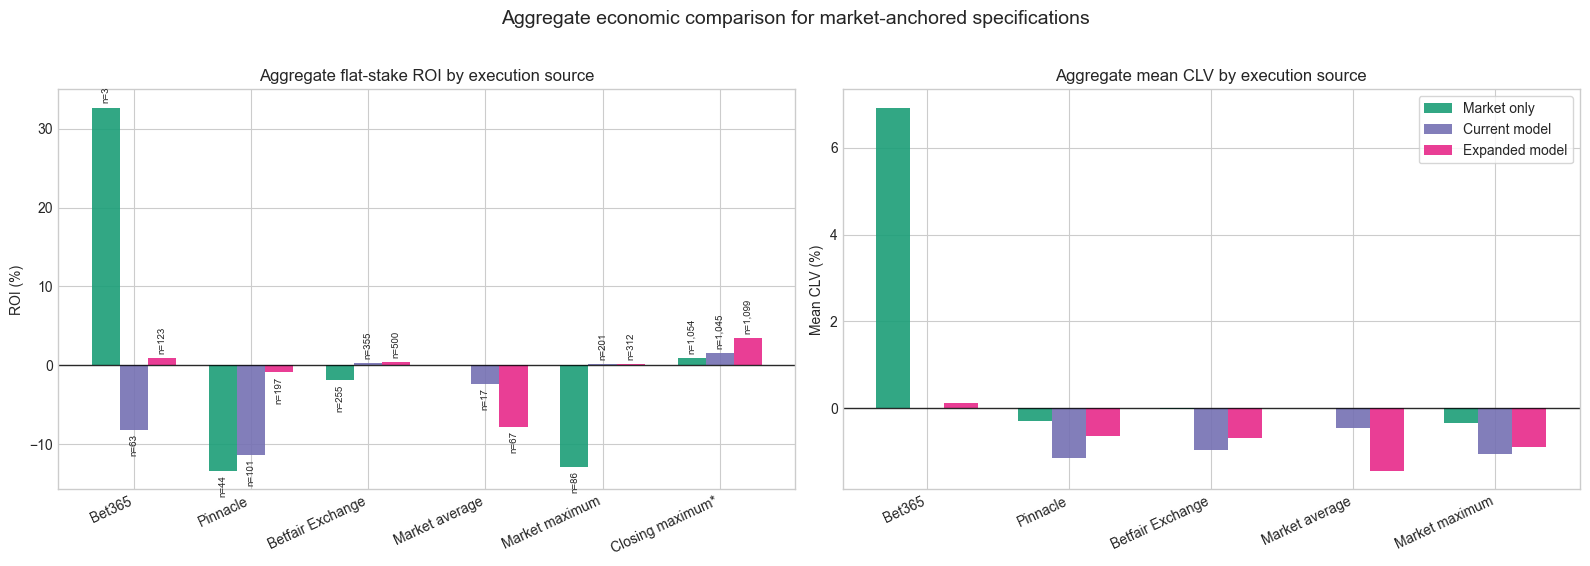

In [19]:
ECONOMIC_COMPARISON_MODELS = ["Market only", "Current model", "Expanded model"]
economic_summary = bet_summary.loc[
    bet_summary["model_name"].isin(ECONOMIC_COMPARISON_MODELS)
].copy()
economic_summary["model_name"] = pd.Categorical(
    economic_summary["model_name"],
    categories=ECONOMIC_COMPARISON_MODELS,
    ordered=True,
)
economic_summary["execution_source"] = pd.Categorical(
    economic_summary["execution_source"],
    categories=SOURCE_ORDER,
    ordered=True,
)
economic_summary = economic_summary.sort_values(["execution_source", "model_name"])

figure, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=False)
bar_width = 0.24
source_x = np.arange(len(SOURCE_ORDER))

for offset_index, model_name in enumerate(ECONOMIC_COMPARISON_MODELS):
    subset = (
        economic_summary.loc[economic_summary["model_name"].eq(model_name)]
        .set_index("execution_source")
        .reindex(SOURCE_ORDER)
    )
    offset = (offset_index - (len(ECONOMIC_COMPARISON_MODELS) - 1) / 2) * bar_width
    roi_bars = axes[0].bar(
        source_x + offset,
        subset["roi_pct"],
        width=bar_width,
        color=MODEL_COLORS[model_name],
        label=model_name,
        alpha=0.9,
    )
    axes[0].bar_label(
        roi_bars,
        labels=["" if pd.isna(value) else f"n={int(value):,}" for value in subset["bets"]],
        padding=3,
        fontsize=7,
        rotation=90,
    )

clv_sources = [source for source in SOURCE_ORDER if source != "best_closing"]
clv_x = np.arange(len(clv_sources))
for offset_index, model_name in enumerate(ECONOMIC_COMPARISON_MODELS):
    subset = (
        economic_summary.loc[economic_summary["model_name"].eq(model_name)]
        .set_index("execution_source")
        .reindex(clv_sources)
    )
    offset = (offset_index - (len(ECONOMIC_COMPARISON_MODELS) - 1) / 2) * bar_width
    axes[1].bar(
        clv_x + offset,
        subset["mean_clv_pct"],
        width=bar_width,
        color=MODEL_COLORS[model_name],
        label=model_name,
        alpha=0.9,
    )

for axis in axes:
    add_zero_line(axis)
    axis.tick_params(axis="x", rotation=25)
axes[0].set_title("Aggregate flat-stake ROI by execution source")
axes[0].set_ylabel("ROI (%)")
axes[0].set_xticks(source_x, [SOURCE_LABELS[source] for source in SOURCE_ORDER], ha="right")
axes[1].set_title("Aggregate mean CLV by execution source")
axes[1].set_ylabel("Mean CLV (%)")
axes[1].set_xticks(clv_x, [SOURCE_LABELS[source] for source in clv_sources], ha="right")
axes[1].legend(loc="best", frameon=True)
figure.suptitle("Aggregate economic comparison for market-anchored specifications", y=1.02, fontsize=14)
figure.tight_layout()
plt.show()

## 8. League-level concentration check

League-level diagnostics are useful, but too many league/source panels can distract from the main market-efficiency question. This section is therefore intentionally compact: it checks whether the economic result for one selected execution source is concentrated in a single championship.

The default source is `best_preclosing`, because it is the main executable market-maximum benchmark. Change `LEAGUE_DIAGNOSTIC_SOURCE` if you want to inspect another venue such as `bet365`, `pinnacle`, `betfair_exchange`, or `average_preclosing`.

These plots are descriptive robustness checks only. They should not be used to choose a league-specific strategy after seeing the results.

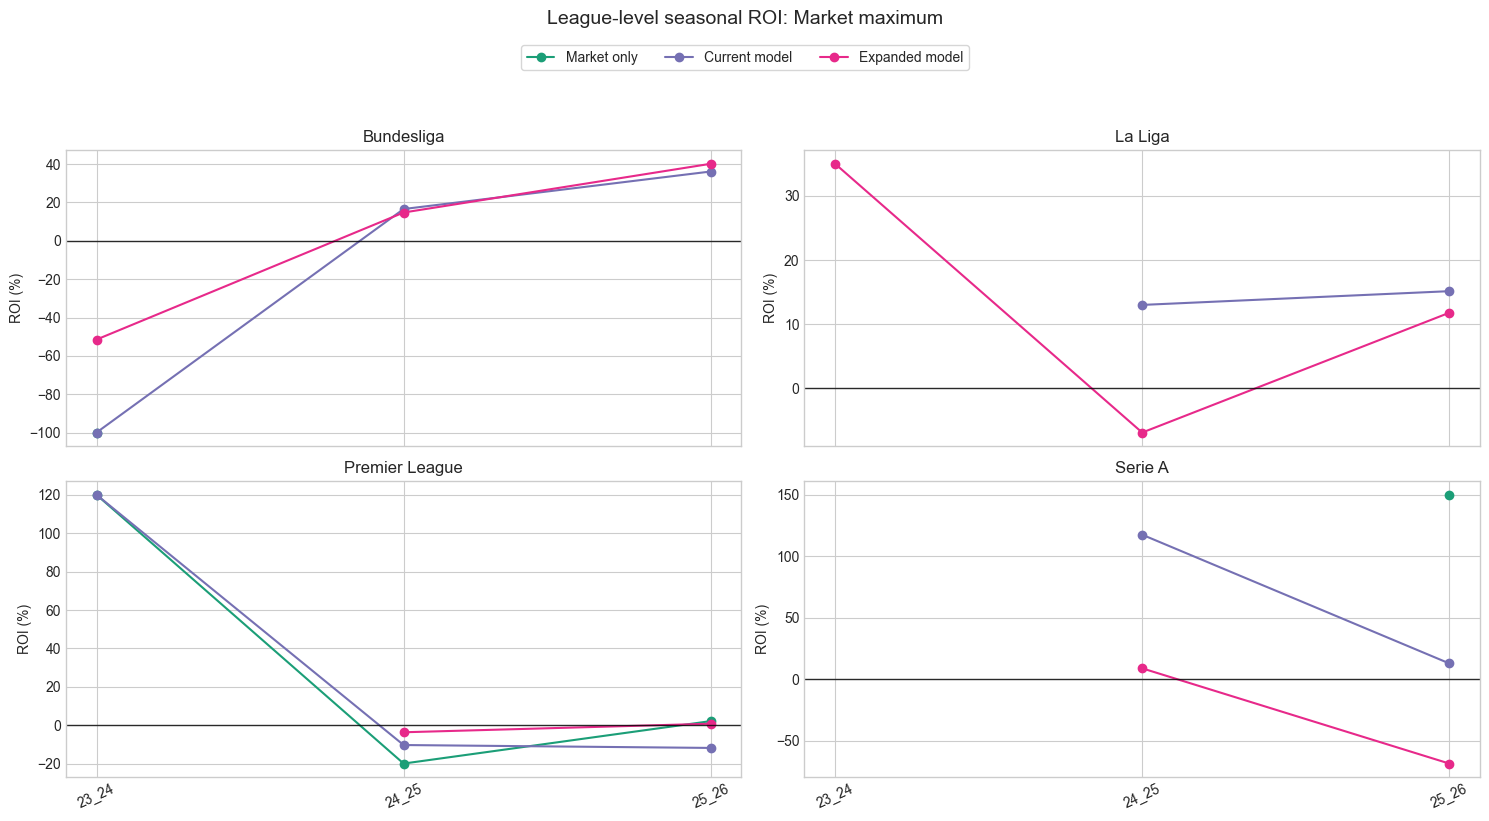

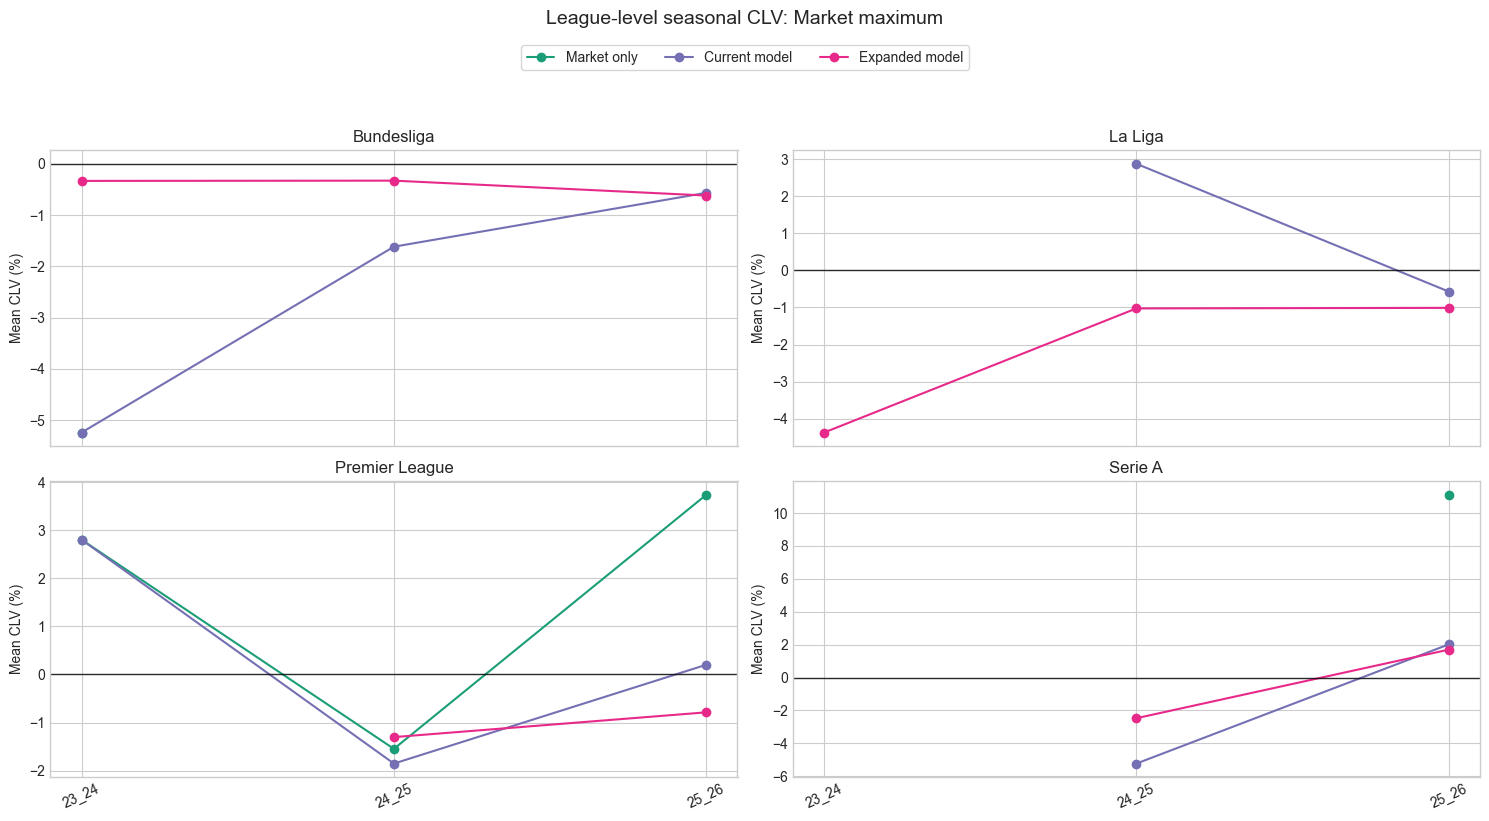

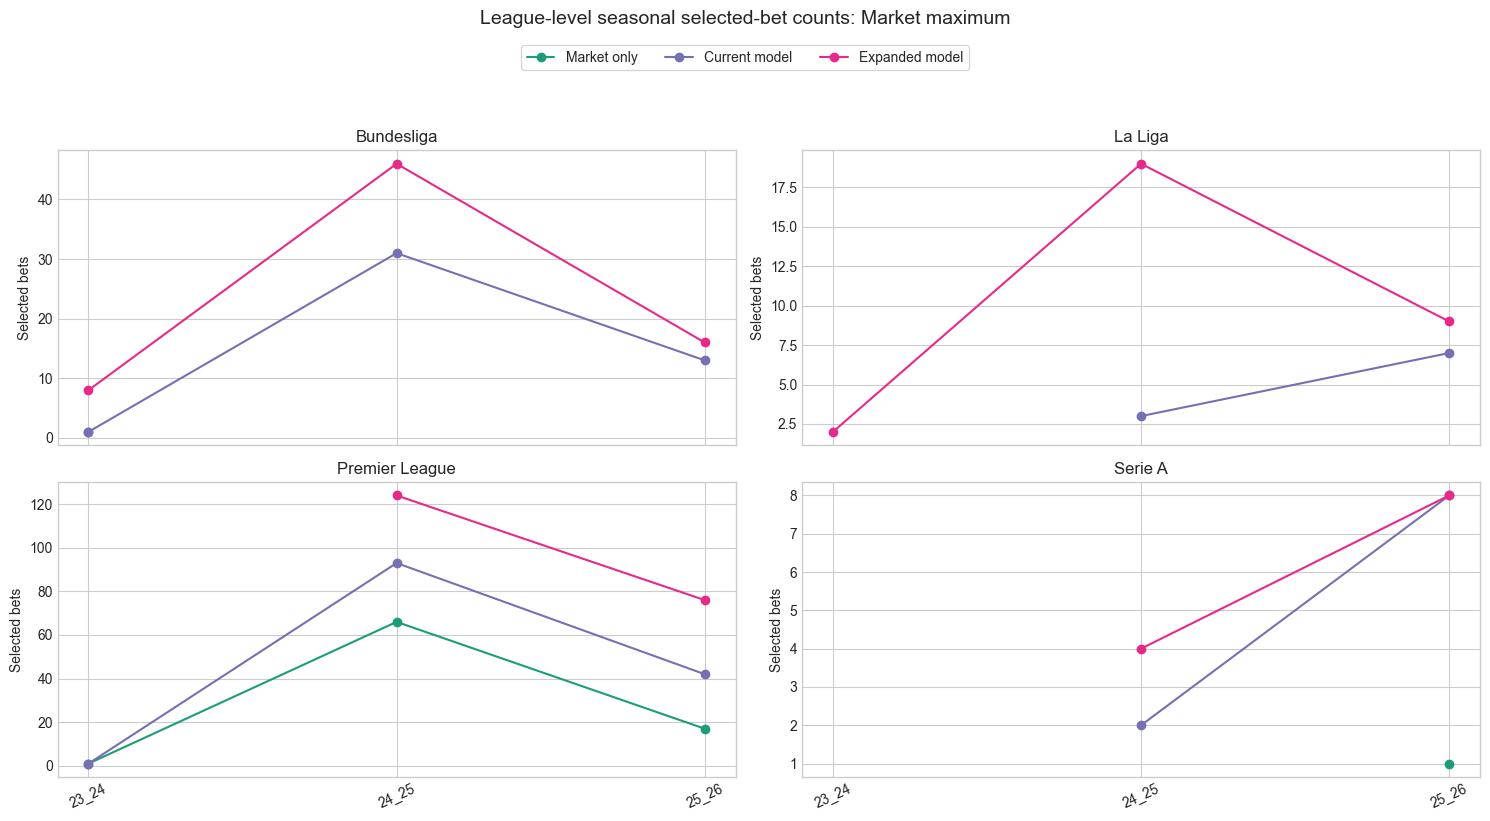

In [20]:
LEAGUE_DIAGNOSTIC_MODELS = ["Market only", "Current model", "Expanded model"]
LEAGUE_DIAGNOSTIC_SOURCE = "best_preclosing"

league_order = sorted(all_bets["league"].dropna().unique())
league_x = np.arange(len(season_order))

league_bet_summary = summarize_bets(
    all_bets.loc[
        all_bets["model_name"].isin(LEAGUE_DIAGNOSTIC_MODELS)
        & all_bets["execution_source"].eq(LEAGUE_DIAGNOSTIC_SOURCE)
    ],
    ["model_name", "league", "season"],
)


def plot_league_metric(metric, ylabel, title, *, zero_line=True):
    figure, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
    axes = axes.ravel()
    handles, labels = [], []
    for axis, league in zip(axes, league_order):
        league_data = league_bet_summary.loc[league_bet_summary["league"].eq(league)]
        for model_name in LEAGUE_DIAGNOSTIC_MODELS:
            model_data = (
                league_data.loc[league_data["model_name"].eq(model_name)]
                .set_index("season")
                .reindex(season_order)
            )
            if model_data[metric].notna().sum() == 0:
                continue
            line = axis.plot(
                league_x,
                model_data[metric],
                marker="o",
                linewidth=1.5,
                color=MODEL_COLORS[model_name],
                label=model_name,
            )[0]
            handles.append(line)
            labels.append(model_name)
        if zero_line:
            add_zero_line(axis)
        axis.set_title(league)
        axis.set_ylabel(ylabel)
        axis.set_xticks(league_x, season_order, rotation=25)
    for axis in axes[len(league_order):]:
        axis.axis("off")
    plot_panel_legend(figure, handles, labels, y=0.985)
    figure.suptitle(
        f"{title}: {SOURCE_LABELS[LEAGUE_DIAGNOSTIC_SOURCE]}",
        y=1.02,
        fontsize=14,
    )
    figure.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


plot_league_metric(
    "roi_pct",
    "ROI (%)",
    "League-level seasonal ROI",
    zero_line=True,
)
plot_league_metric(
    "mean_clv_pct",
    "Mean CLV (%)",
    "League-level seasonal CLV",
    zero_line=True,
)
plot_league_metric(
    "bets",
    "Selected bets",
    "League-level seasonal selected-bet counts",
    zero_line=False,
)

## 9. Bet-count diagnostics: monthly, yearly, and full history

Sample size is a first-order issue. A model that looks good but places very few bets, or concentrates bets in one short period, should not be promoted to the main strategy.

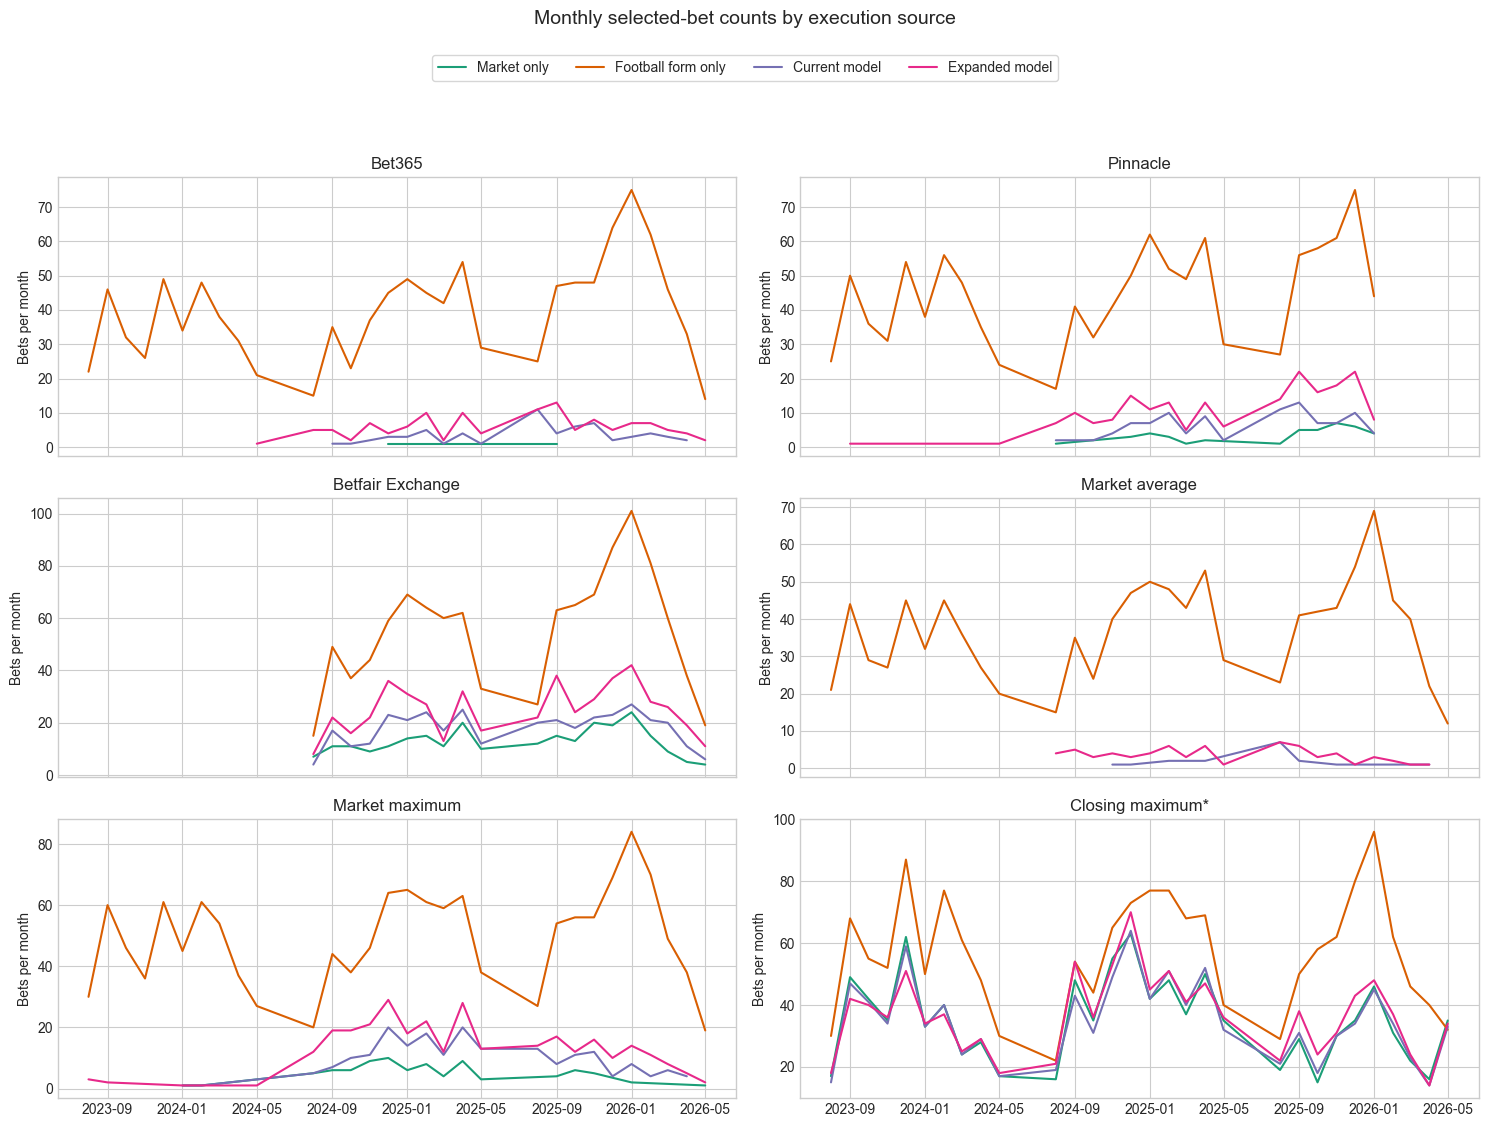

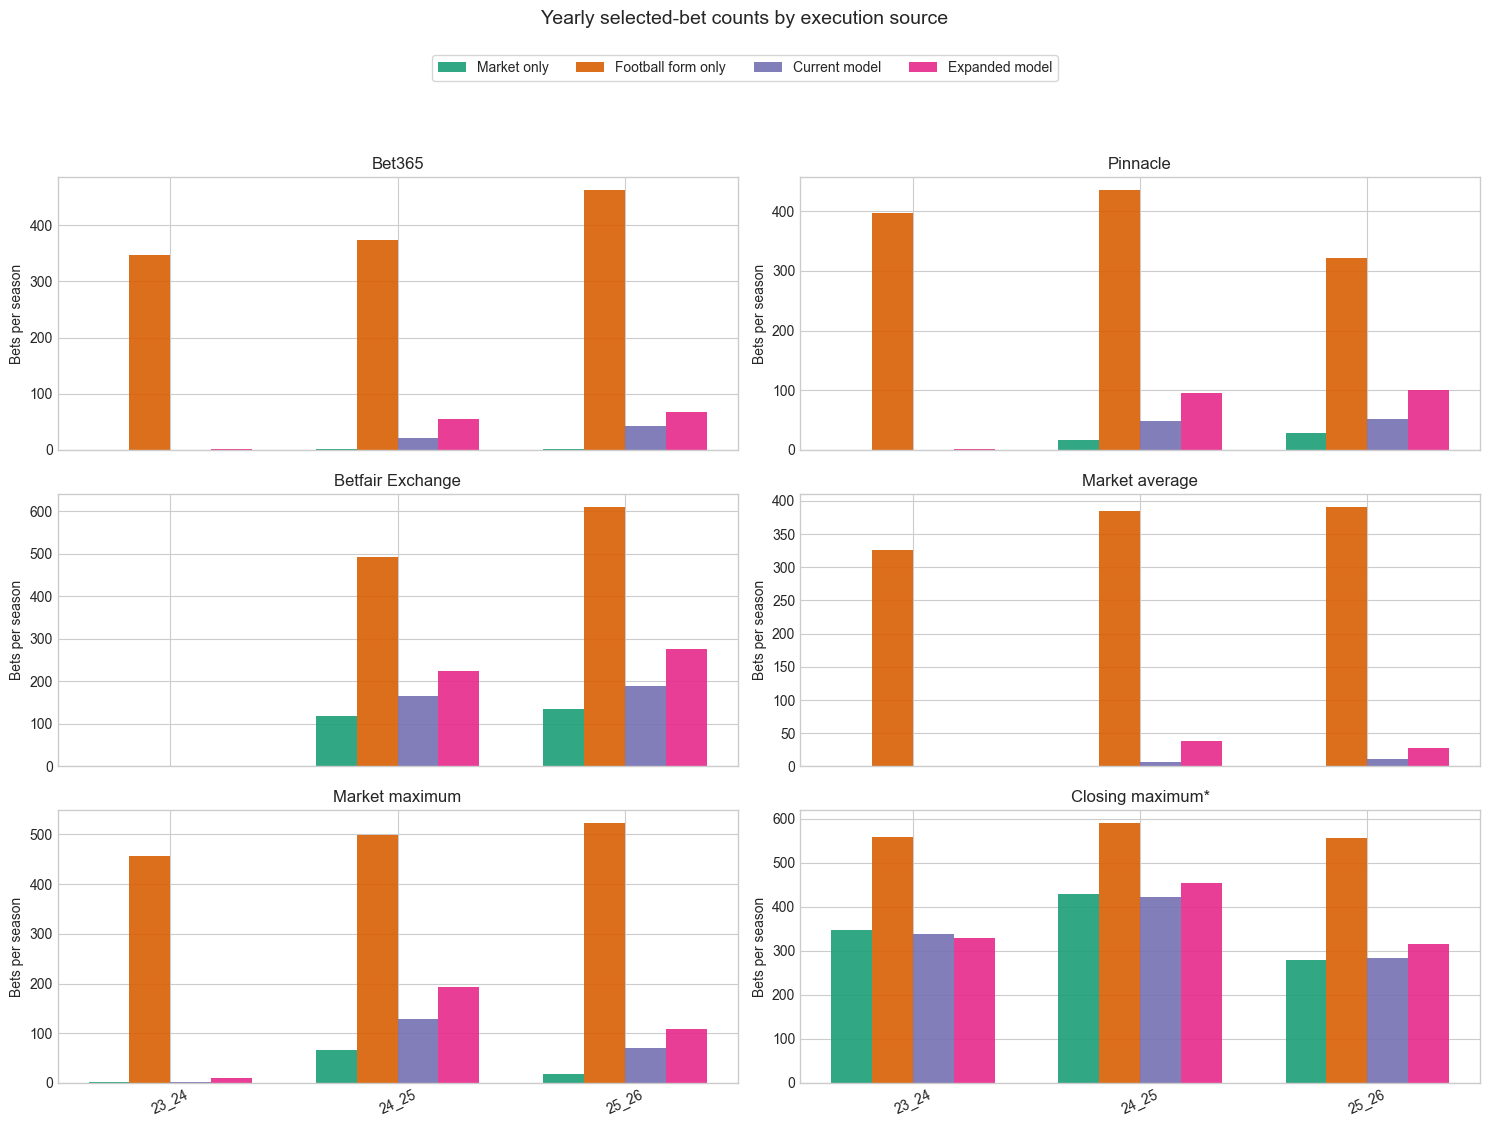

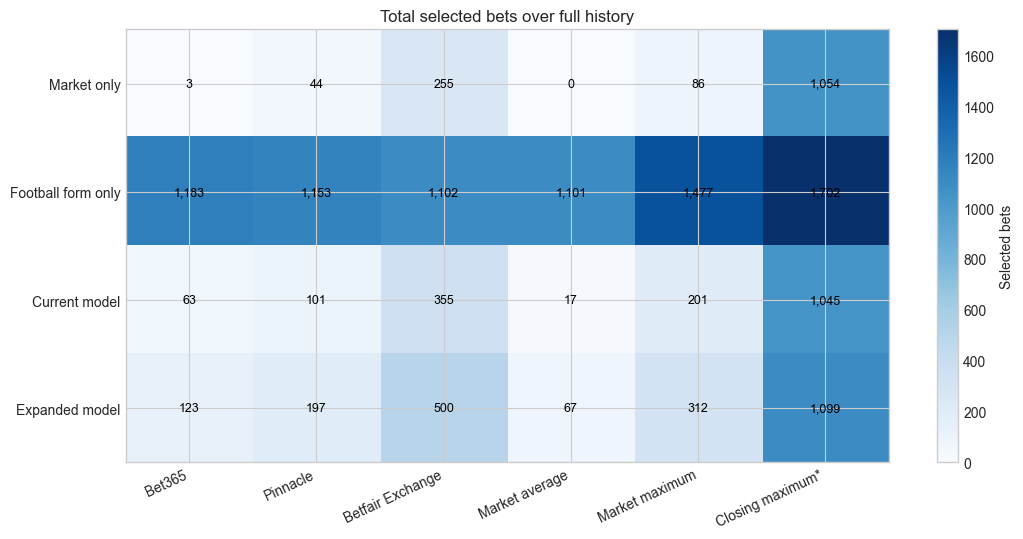

In [21]:
monthly_counts = monthly_roi(all_bets, ["model_name", "execution_source"])
yearly_counts = (
    all_bets.groupby(["model_name", "execution_source", "season"], sort=True, observed=True)
    .size()
    .rename("bets")
    .reset_index()
)
total_counts = (
    all_bets.groupby(["model_name", "execution_source"], sort=True, observed=True)
    .size()
    .rename("bets")
    .reset_index()
)

figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
handles, labels = [], []
for axis, source in zip(axes, SOURCE_ORDER):
    subset = monthly_counts.loc[monthly_counts["execution_source"].eq(source)]
    for model_name in MODEL_ORDER:
        model_subset = subset.loc[subset["model_name"].eq(model_name)].sort_values("month")
        line = axis.plot(
            model_subset["month"],
            model_subset["bets"],
            linewidth=1.5,
            color=MODEL_COLORS[model_name],
            label=model_name,
        )[0]
        handles.append(line)
        labels.append(model_name)
    axis.set_title(SOURCE_LABELS[source])
    axis.set_ylabel("Bets per month")

plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Monthly selected-bet counts by execution source", y=1.02, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
width = 0.18
x = np.arange(len(season_order))
for axis, source in zip(axes, SOURCE_ORDER):
    subset = yearly_counts.loc[yearly_counts["execution_source"].eq(source)]
    for offset_index, model_name in enumerate(MODEL_ORDER):
        values = (
            subset.loc[subset["model_name"].eq(model_name)]
            .set_index("season")
            .reindex(season_order)["bets"]
            .fillna(0)
        )
        offset = (offset_index - (len(MODEL_ORDER) - 1) / 2) * width
        axis.bar(x + offset, values, width=width, color=MODEL_COLORS[model_name], label=model_name, alpha=0.9)
    axis.set_title(SOURCE_LABELS[source])
    axis.set_ylabel("Bets per season")
    axis.set_xticks(x, season_order, rotation=25)

handles, labels = axes[0].get_legend_handles_labels()
plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Yearly selected-bet counts by execution source", y=1.02, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

count_matrix = (
    total_counts.pivot(index="model_name", columns="execution_source", values="bets")
    .reindex(index=MODEL_ORDER, columns=SOURCE_ORDER)
    .fillna(0)
)
figure, axis = plt.subplots(figsize=(11, 5.5))
image = axis.imshow(count_matrix, cmap="Blues", aspect="auto")
axis.set_xticks(np.arange(len(SOURCE_ORDER)), [SOURCE_LABELS[source] for source in SOURCE_ORDER], rotation=25, ha="right")
axis.set_yticks(np.arange(len(MODEL_ORDER)), MODEL_ORDER)
axis.set_title("Total selected bets over full history")
for i, model_name in enumerate(MODEL_ORDER):
    for j, source in enumerate(SOURCE_ORDER):
        value = count_matrix.loc[model_name, source]
        axis.text(j, i, f"{int(value):,}", ha="center", va="center", color="black", fontsize=9)
figure.colorbar(image, ax=axis, label="Selected bets")
figure.tight_layout()
plt.show()

## 10. Cumulative profit paths

Cumulative paths reveal whether aggregate performance is persistent or concentrated in a short interval. These plots use one-unit flat stakes and should be interpreted together with CLV and bet counts.

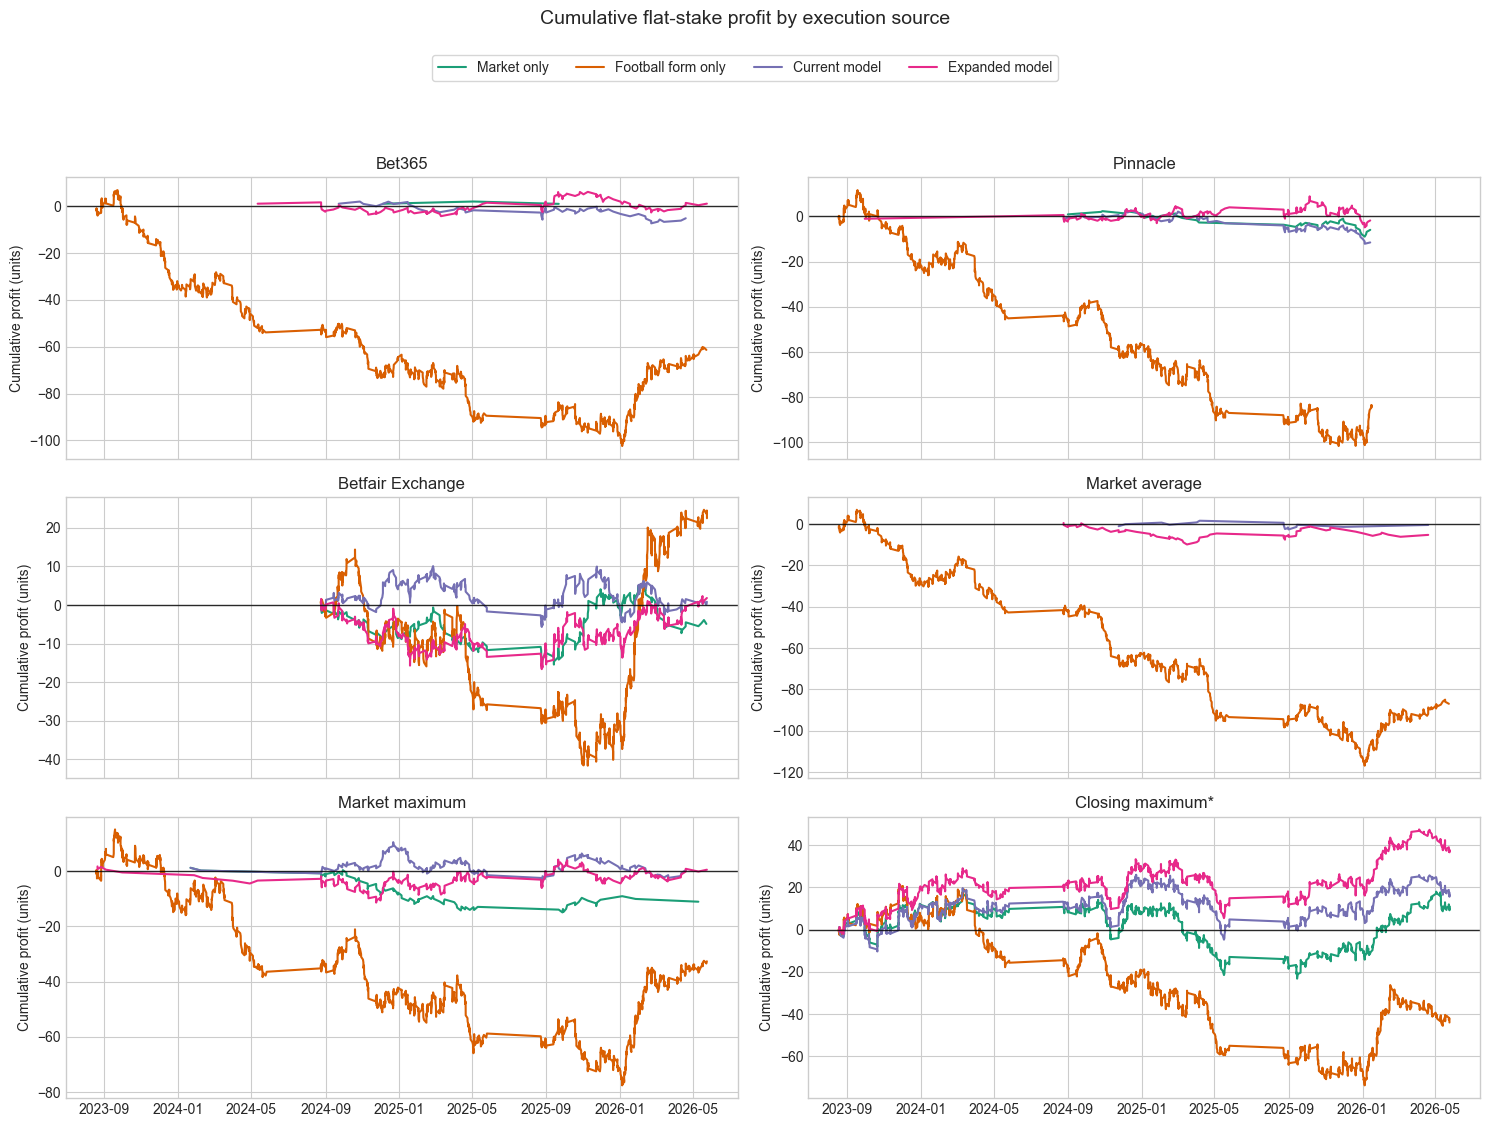

In [22]:
figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
axes = axes.ravel()
handles, labels = [], []
for axis, source in zip(axes, SOURCE_ORDER):
    subset = all_bets.loc[all_bets["execution_source"].eq(source)]
    for model_name in MODEL_ORDER:
        path = subset.loc[subset["model_name"].eq(model_name)].sort_values("date", kind="stable").copy()
        if path.empty:
            continue
        path["cumulative_profit"] = path["profit"].cumsum()
        line = axis.plot(
            path["date"],
            path["cumulative_profit"],
            linewidth=1.5,
            color=MODEL_COLORS[model_name],
            label=model_name,
        )[0]
        handles.append(line)
        labels.append(model_name)
    add_zero_line(axis)
    axis.set_title(SOURCE_LABELS[source])
    axis.set_ylabel("Cumulative profit (units)")

plot_panel_legend(figure, handles, labels, y=0.985)
figure.suptitle("Cumulative flat-stake profit by execution source", y=1.02, fontsize=14)
figure.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 11. Regularization sensitivity across years

This section varies only the L2 penalty for the two market-anchored feature specifications: current model and expanded model. The purpose is not to optimize a new parameter, but to check whether conclusions about incremental form value are stable under stronger or weaker regularization.

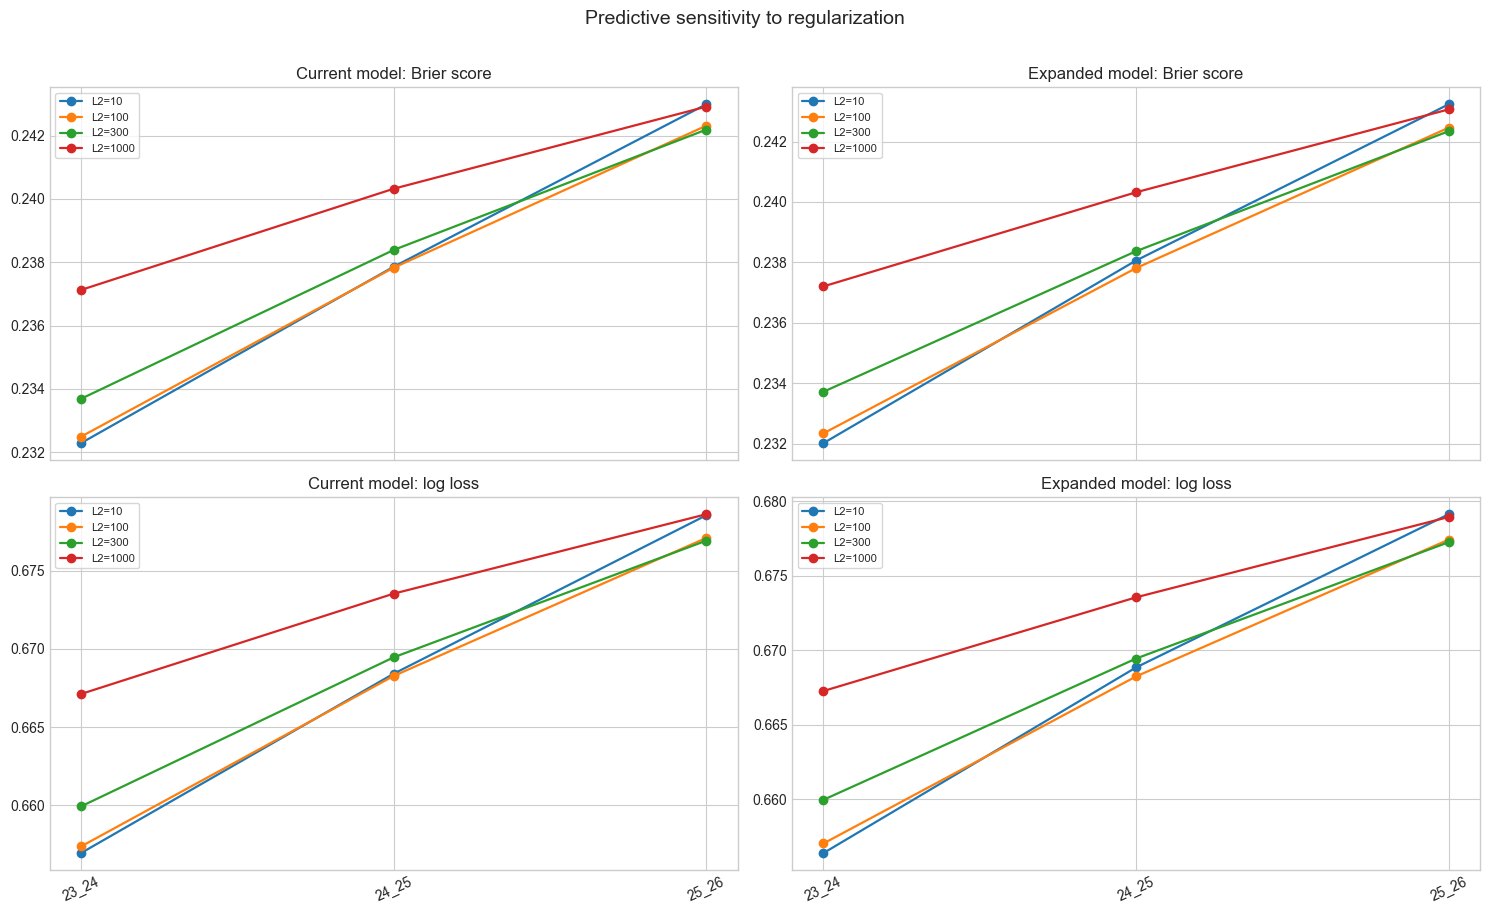

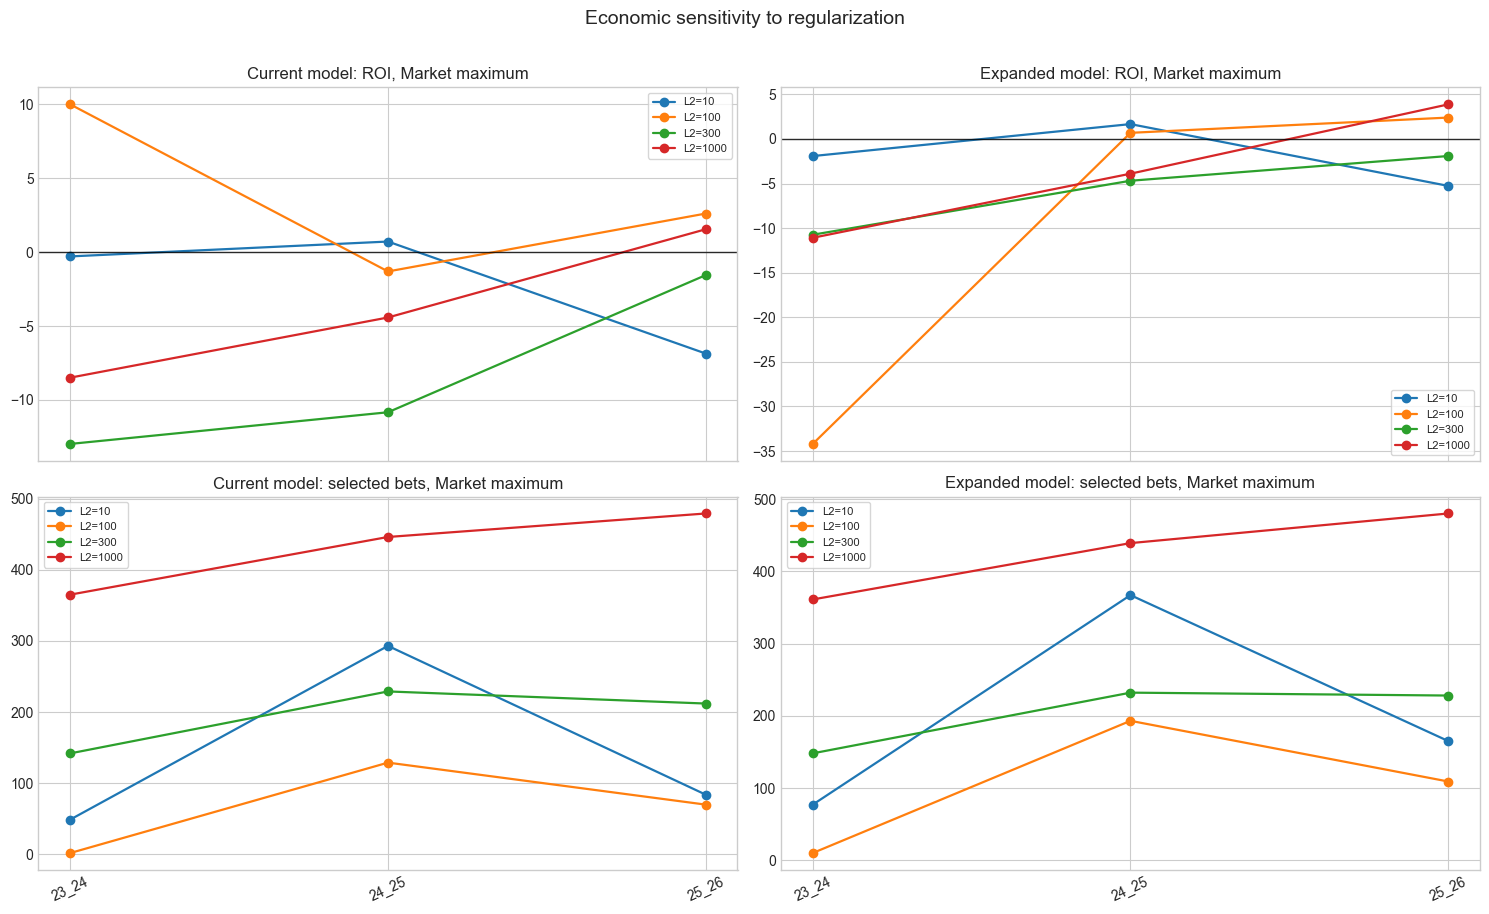

In [23]:
sensitivity_frames = []
sensitivity_bets = []
for model_base_name, features in {
    "Current model": MODEL_SPECS["Current model"],
    "Expanded model": MODEL_SPECS["Expanded model"],
}.items():
    for l2 in SENSITIVITY_L2_VALUES:
        model_name = f"{model_base_name} | L2={l2:g}"
        predictions, _ = run_pooled_rolling_walk_forward(
            analysis_matches,
            l2=l2,
            model_name=model_name,
            training_window=TRAINING_WINDOW,
            feature_columns=features,
        )
        predictions["model_base"] = model_base_name
        predictions["regularization_l2"] = l2
        sensitivity_frames.append(predictions)

        candidates = build_execution_candidates(
            predictions,
            include_closing_prices=True,
            probability_column="model_probability",
        )
        bets = candidates.loc[candidates["expected_value"].ge(EV_THRESHOLD)].copy()
        bets["model_base"] = model_base_name
        bets["regularization_l2"] = l2
        sensitivity_bets.append(bets)

sensitivity_predictions = pd.concat(sensitivity_frames, ignore_index=True)
sensitivity_bets = pd.concat(sensitivity_bets, ignore_index=True)
sensitivity_performance = probability_performance(
    sensitivity_predictions,
    probability_column="model_probability",
    group_by=["model_base", "regularization_l2", "season"],
)
sensitivity_bet_summary = summarize_bets(
    sensitivity_bets,
    ["model_base", "regularization_l2", "execution_source", "season"],
)

figure, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
axes = axes.ravel()
sensitivity_plot_specs = [
    ("Current model", "brier_score", "Current model: Brier score"),
    ("Expanded model", "brier_score", "Expanded model: Brier score"),
    ("Current model", "log_loss", "Current model: log loss"),
    ("Expanded model", "log_loss", "Expanded model: log loss"),
]
for axis, (model_base, metric, title) in zip(axes, sensitivity_plot_specs):
    subset = sensitivity_performance.loc[sensitivity_performance["model_base"].eq(model_base)]
    for l2 in SENSITIVITY_L2_VALUES:
        l2_subset = subset.loc[subset["regularization_l2"].eq(l2)]
        axis.plot(l2_subset["season"], l2_subset[metric], marker="o", linewidth=1.6, label=f"L2={l2:g}")
    axis.set_title(title)
    axis.tick_params(axis="x", rotation=25)
    axis.legend(fontsize=8, frameon=True)

figure.suptitle("Predictive sensitivity to regularization", y=1.01, fontsize=14)
figure.tight_layout()
plt.show()

SENSITIVITY_SOURCE = "best_preclosing"
sensitivity_source = sensitivity_bet_summary.loc[
    sensitivity_bet_summary["execution_source"].eq(SENSITIVITY_SOURCE)
]
figure, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
axes = axes.ravel()
for axis, model_base in zip(axes[:2], ["Current model", "Expanded model"]):
    subset = sensitivity_source.loc[sensitivity_source["model_base"].eq(model_base)]
    for l2 in SENSITIVITY_L2_VALUES:
        l2_subset = subset.loc[subset["regularization_l2"].eq(l2)]
        axis.plot(l2_subset["season"], l2_subset["roi_pct"], marker="o", linewidth=1.6, label=f"L2={l2:g}")
    add_zero_line(axis)
    axis.set_title(f"{model_base}: ROI, {SOURCE_LABELS[SENSITIVITY_SOURCE]}")
    axis.tick_params(axis="x", rotation=25)
    axis.legend(fontsize=8, frameon=True)
for axis, model_base in zip(axes[2:], ["Current model", "Expanded model"]):
    subset = sensitivity_source.loc[sensitivity_source["model_base"].eq(model_base)]
    for l2 in SENSITIVITY_L2_VALUES:
        l2_subset = subset.loc[subset["regularization_l2"].eq(l2)]
        axis.plot(l2_subset["season"], l2_subset["bets"], marker="o", linewidth=1.6, label=f"L2={l2:g}")
    axis.set_title(f"{model_base}: selected bets, {SOURCE_LABELS[SENSITIVITY_SOURCE]}")
    axis.tick_params(axis="x", rotation=25)
    axis.legend(fontsize=8, frameon=True)

figure.suptitle("Economic sensitivity to regularization", y=1.01, fontsize=14)
figure.tight_layout()
plt.show()

## 12. Conclusions

**Main market-efficiency conclusion.**  
Simple football-form features do **not** add robust out-of-sample information beyond the market-implied probability in this experiment. The clean benchmark is market-only, and it remains the strongest aggregate predictive model: market-only Brier/log loss is **0.237438 / 0.667395**, while the current market-plus-attack model is **0.237543 / 0.667574** and the expanded attack-plus-defense model is **0.237539 / 0.667569**. These differences are tiny, but directionally they favor the market-only benchmark.

**Current model versus market-only.**  
The current model asks whether attacking-form features improve the market logit. On the full out-of-sample sample, they do not. The current model is slightly worse than market-only in aggregate Brier score and log loss. Season-level differences are very small, so this should not be interpreted as a major failure of the current model; rather, it shows that the market already captures most of this simple public form information.

**Expanded model versus market-only.**  
The expanded model asks whether attacking plus defensive/conceded-goal features improve the market logit. It also does not beat market-only in aggregate predictive metrics. The expanded model slightly improves versus the current model in **2023/24** and **2024/25**, but slightly worsens in **2025/26**. The improvement is too small and too unstable to justify calling the defensive features robust incremental predictors.

**Football-form-only benchmark.**  
The football-form-only model is clearly worse than all market-anchored variants, with aggregate Brier/log loss of **0.242944 / 0.678833**. This is an important sanity check: simple team form has football intuition and some standalone predictive signal, but it is not competitive with bookmaker consensus probabilities.

**Calibration and coefficients.**  
The expanded model has an aggregate calibration slope close to one (**0.9995**), and the current model is also close (**1.0023**). The market-only model is also well calibrated (**1.0227**) and has better aggregate scoring metrics. Coefficient stability supports the same interpretation: the market-logit coefficient is stable and dominant, while attacking and defensive form coefficients are much smaller and less stable across folds.

**Economic diagnostics.**  
Some realized ROI pockets improve with the expanded model, but the evidence remains weak. Bet365 improves from **-8.21% ROI** to **+0.87% ROI**, Pinnacle improves from **-11.38%** to **-0.89%**, and Betfair Exchange improves slightly from **+0.24%** to **+0.36%**. However, market maximum is essentially unchanged, average pre-closing worsens, and CLV remains mostly weak or negative. This means the economic plots do not overturn the predictive conclusion.

**Decision.**  
I would **not promote the expanded feature set to the main model**. Notebook 07 is still valuable as a professional robustness experiment: it tests a plausible football intuition, uses a fair common sample, benchmarks directly against the market, and finds that the added features do not materially improve out-of-sample performance. The result strengthens the project because it shows restraint: the model remains market-anchored and parsimonious unless extra football features prove stable incremental value.